In [1]:

import numpy as np
import matplotlib.pyplot as plt

import qil_SpinHamiltonian.spin_hamiltonian as spin
import qil_SpinHamiltonian.search as spinSearch
h=spin.h

# Manual Instantiation

In [2]:
Espin=0
Ispin=5/2

#Natural units of the program are GHz, T and radians so conversions must be made
M=np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h
Q=np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h
alpha,beta,gamma=np.array([-99.8,55.8,-40])*np.pi/180

#No convention for rotation is specified in the data source, but ZYZ is typical
M=spin.tensorRotation(M,[alpha,beta,gamma],conv='ZYZ')
Q=spin.tensorRotation(Q,[alpha,beta,gamma],conv='ZYZ')

#Instantiates the class and sets up dimensions and spin matricies
ground = spin.cSpinHamiltonian(Espin,Ispin)

#pass these matricies to the class
ground.setM(M)
#This will calculate and store the interaction in our static hamiltonian
ground.quadrupoleInteraction(Q)
print(ground.H.shape) #Access the static hamiltonian it big so lets just print its shape



(6, 6)


# Import Hamiltonian

In [3]:
groundI=spin.hamilFromYAML('../ion_params/Pr_YSO.yml')
#We can also change the spin values if we want to look at other isotopes
    #Lets pretend Pr has a stable spin 3/2 isotope
groundN=spin.hamilFromYAML('../ion_params/Pr_YSO.yml',IOveride=3/2)

{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}
{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}


# Do some field stuff

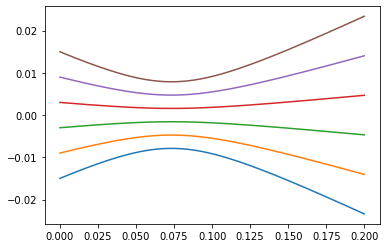

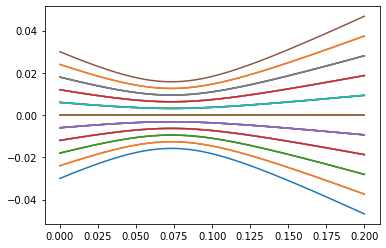

In [4]:
#generate a set of fields from zero to 100mT
Bz=np.linspace(0,200*1E-3,200)
#Unit vector along z
uvec=np.matrix([0,0,1]).T

#convert it to a vector along the our axis
B=uvec*Bz

#If we are doing simple things dynamicH suffices
    # It automatically adds the static hamiltonian if static=True
H=groundI.dynamicH(B)

#This actually conceals a few important things so to write it out in full
    #ground.H contains our static hamiltonian, 
    #it doesn't know about the dimension of the magnetic field
    #Using np.newaxis we can increase the dimension to match the zeeman data
H=np.array(groundI.H)[np.newaxis,...]-groundI.nuclearZeeman(B)

#get the eigen values F and Vectors
F,V=groundI.getEigFreq(H)

#Dimension convention makes is to aid such plotting
plt.plot(Bz,F)
plt.show()

#Calculate the transitions, noting that our transitions always lie across axis 1
T=spin.eachElemFunc(F,F,axis=1)
plt.plot(Bz,T)
plt.show()


# Gradient

dH Shape:  (3, 6, 6)


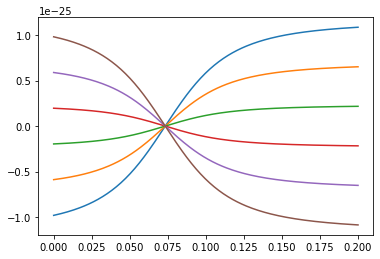

In [5]:
#This uses the default calculated hamiltonian derivative based on dynamicH
df=groundI.gradient(V)

#To be explicit we just calculate the gradient as the value at the Identity
    #This generates the three x,y,z hamiltonian elements that are then seperated
dH=-groundI.nuclearZeeman(np.eye(3))
print("dH Shape: ",dH.shape)
df=groundI.gradient(V,dH=dH)
plt.plot(Bz,df.real*uvec)
plt.show()

# Curvature

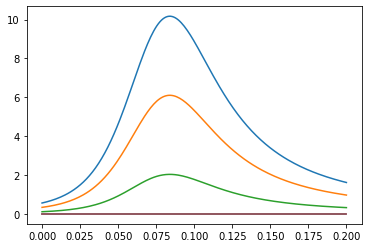

In [6]:
ddf=groundI.curvature(V,F)
#plot the maximum eigenvalue as a single proxy
Cmax=np.max(np.linalg.eig(ddf)[0],axis=-1)
plt.plot(Bz,Cmax.real)
plt.show()